# PR.3 — Deep Learning Project Solution
### Morphological Operations • Bitwise Operations • Face Detection • YOLO Object Detection

> This notebook is a ready-to-run implementation based on the project brief.  
> Update the image paths and dataset paths in the configuration cell before running.


## 0. Install / import packages

In [4]:
# Run this cell once if packages are missing
# %pip install opencv-python numpy matplotlib pandas ultralytics

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)


OpenCV: 5.0.0


## 1. Configuration

In [5]:
# CHANGE THESE PATHS
IMAGE_PATH = "images/test.jpg"
SAMPLE_DIR = "images"
YOLO_IMAGE_DIR = "images"       # folder containing test images
YOLO_MODEL = "yolov8n.pt"       # pretrained COCO model

os.makedirs("outputs", exist_ok=True)

print("Image path:", IMAGE_PATH)


Image path: images/test.jpg


## 1.1 Load and display an image

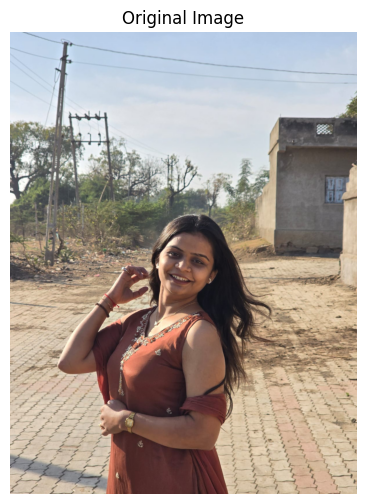

In [6]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(
        f"Could not load {IMAGE_PATH}. Put an image there or change IMAGE_PATH."
    )

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


## Task 1 — Morphological Operations

### 1.2 Binarize a test image

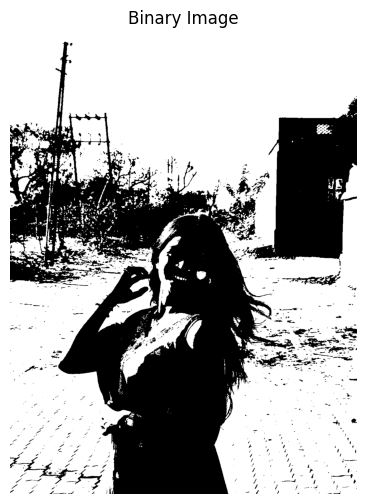

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY
)

plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()


### 1.3 Apply erosion, dilation, opening and closing

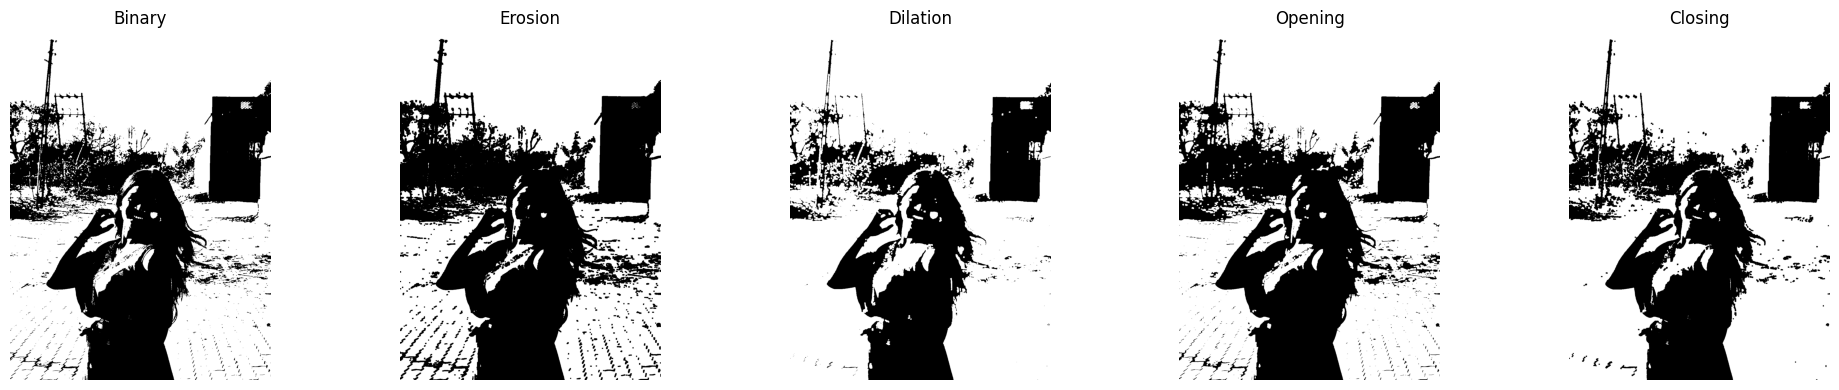

In [8]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
results = [
    ("Binary", binary),
    ("Erosion", erosion),
    ("Dilation", dilation),
    ("Opening", opening),
    ("Closing", closing),
]

for ax, (title, image) in zip(axes, results):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


### 1.4 Kernel-size comparison

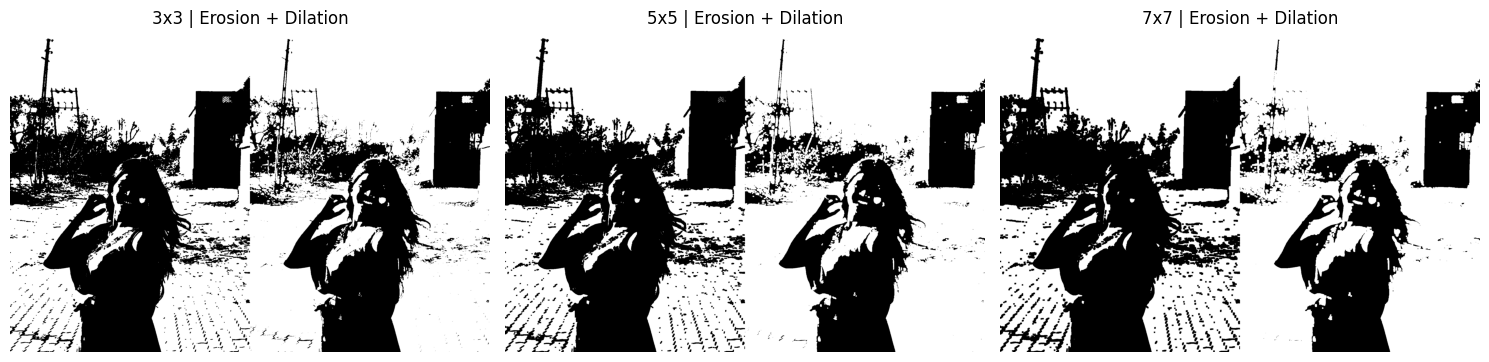

In [9]:
kernel_sizes = [3, 5, 7]

fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(15, 4))

for ax, size in zip(axes, kernel_sizes):
    k = np.ones((size, size), np.uint8)
    er = cv2.erode(binary, k, iterations=1)
    di = cv2.dilate(binary, k, iterations=1)

    # Show erosion and dilation side-by-side in one panel
    comparison = np.hstack([er, di])
    ax.imshow(comparison, cmap="gray")
    ax.set_title(f"{size}x{size} | Erosion + Dilation")
    ax.axis("off")

plt.tight_layout()
plt.show()


### 1.5 Morphology — interpretation

In [10]:
print("Morphological interpretation:")
print("- Erosion shrinks foreground regions and can remove small white noise.")
print("- Dilation expands foreground regions and can fill small gaps.")
print("- Opening = erosion followed by dilation; useful for removing small noise.")
print("- Closing = dilation followed by erosion; useful for closing small holes/gaps.")
print("- A larger kernel produces a stronger morphological effect.")


Morphological interpretation:
- Erosion shrinks foreground regions and can remove small white noise.
- Dilation expands foreground regions and can fill small gaps.
- Opening = erosion followed by dilation; useful for removing small noise.
- Closing = dilation followed by erosion; useful for closing small holes/gaps.
- A larger kernel produces a stronger morphological effect.


## Task 2 — Bitwise Operations & Image Histograms

### 2.1 Bitwise AND / OR / XOR / NOT

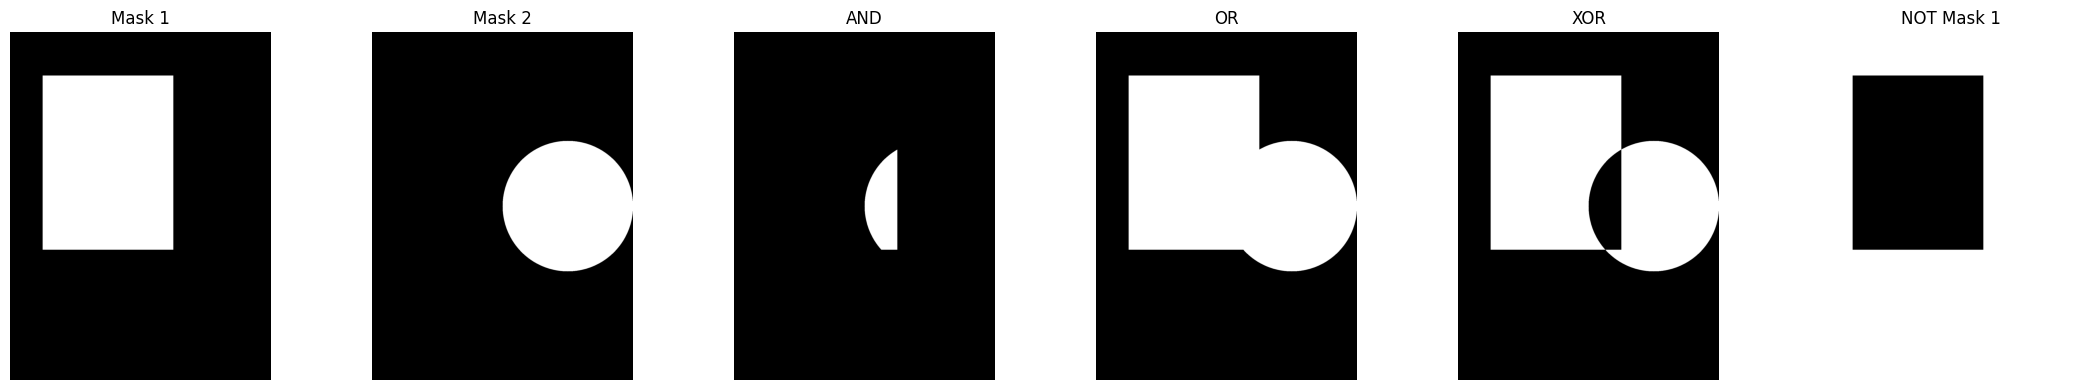

In [11]:
# Create two simple masks
h, w = gray.shape
mask1 = np.zeros((h, w), dtype=np.uint8)
mask2 = np.zeros((h, w), dtype=np.uint8)

cv2.rectangle(mask1, (w//8, h//8), (5*w//8, 5*h//8), 255, -1)
cv2.circle(mask2, (3*w//4, h//2), min(h, w)//4, 255, -1)

bitwise_and = cv2.bitwise_and(mask1, mask2)
bitwise_or  = cv2.bitwise_or(mask1, mask2)
bitwise_xor = cv2.bitwise_xor(mask1, mask2)
bitwise_not = cv2.bitwise_not(mask1)

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
items = [
    ("Mask 1", mask1),
    ("Mask 2", mask2),
    ("AND", bitwise_and),
    ("OR", bitwise_or),
    ("XOR", bitwise_xor),
    ("NOT Mask 1", bitwise_not),
]

for ax, (title, image) in zip(axes, items):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


### 2.2 Applied use-case — mask a region of interest

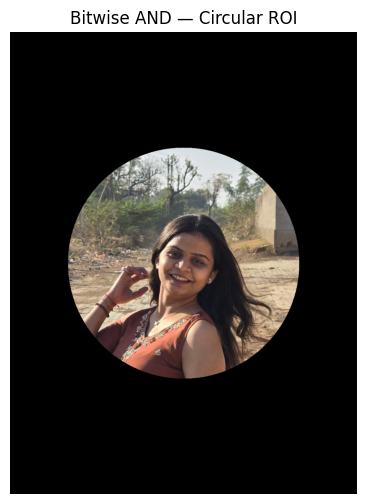

In [12]:
# Apply a circular ROI mask to the original image
roi_mask = np.zeros(img.shape[:2], dtype=np.uint8)
cv2.circle(
    roi_mask,
    (img.shape[1] // 2, img.shape[0] // 2),
    min(img.shape[:2]) // 3,
    255,
    -1
)

roi = cv2.bitwise_and(img, img, mask=roi_mask)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Bitwise AND — Circular ROI")
plt.axis("off")
plt.show()


### 2.3 Grayscale and per-channel histograms

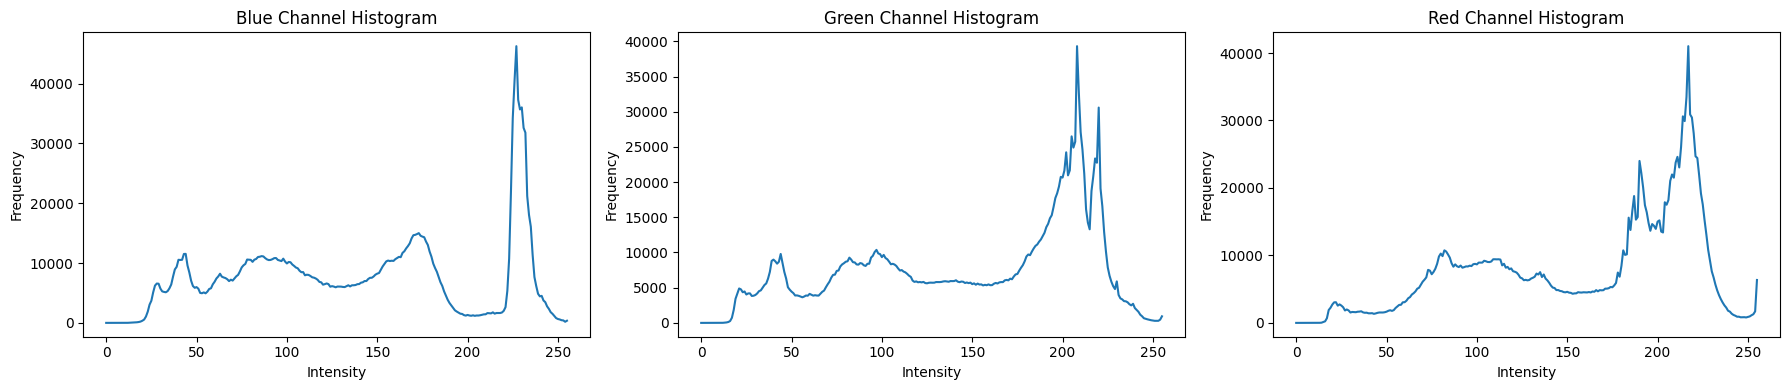

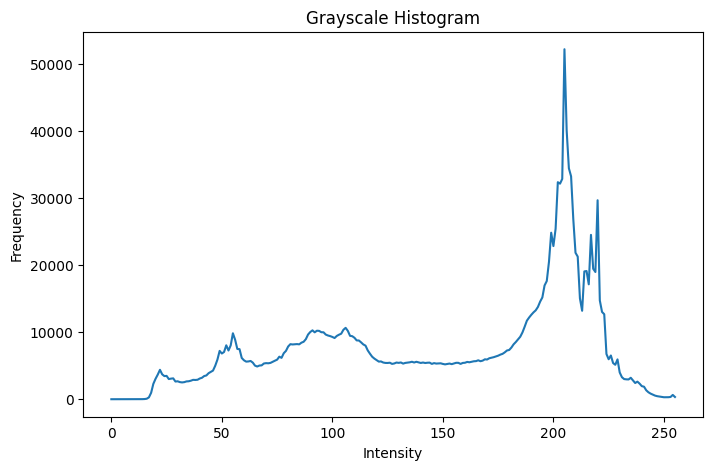

In [13]:
channels = cv2.split(img)
channel_names = ["Blue", "Green", "Red"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, channel, name in zip(axes, channels, channel_names):
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    ax.plot(hist)
    ax.set_title(f"{name} Channel Histogram")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 5))
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()


### 2.4 Brightness and contrast adjustment

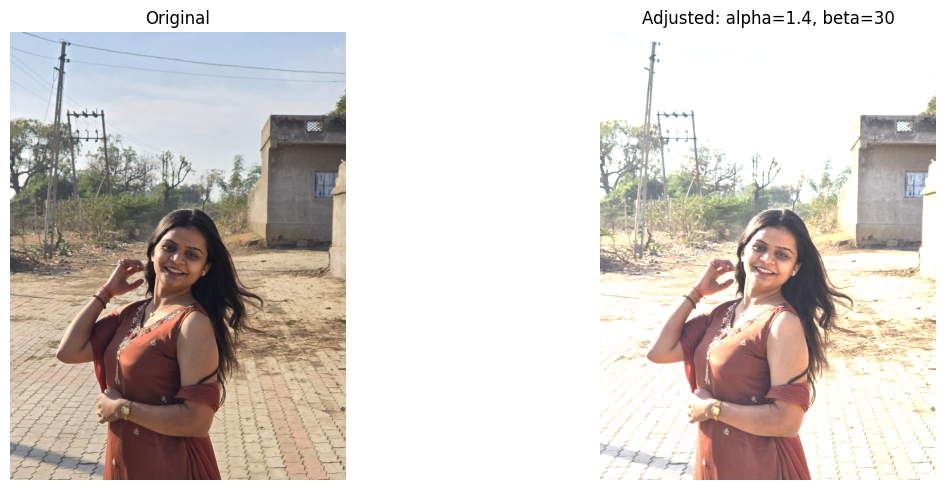

In [14]:
alpha = 1.4   # contrast
beta = 30      # brightness

adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Adjusted: alpha={alpha}, beta={beta}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


### 2.5 Why histograms matter

In [15]:
print("Histogram interpretation:")
print("- A histogram shows the distribution of pixel intensities.")
print("- A histogram concentrated on the left usually indicates a darker image.")
print("- A histogram concentrated on the right usually indicates a brighter image.")
print("- A narrow distribution often indicates lower contrast.")
print("- A wider distribution generally indicates higher contrast.")


Histogram interpretation:
- A histogram shows the distribution of pixel intensities.
- A histogram concentrated on the left usually indicates a darker image.
- A histogram concentrated on the right usually indicates a brighter image.
- A narrow distribution often indicates lower contrast.
- A wider distribution generally indicates higher contrast.


## Task 3 — Face Detection with YuNet (OpenCV 5.0 / OpenCV Zoo)

### 3.1 Download/load the YuNet face detector

In [16]:
# If the model file is not present, download it manually from OpenCV Zoo:
# face_detection_yunet_2023mar.onnx
#
# Put it in: models/face_detection_yunet_2023mar.onnx

YUNET_MODEL = "models/face_detection_yunet_2023mar.onnx"

if not os.path.exists(YUNET_MODEL):
    print("YuNet model not found.")
    print("Download face_detection_yunet_2023mar.onnx and place it in the models folder.")
else:
    face_detector = cv2.FaceDetectorYN.create(
        YUNET_MODEL,
        "",
        (320, 320),
        score_threshold=0.9,
        nms_threshold=0.3,
        top_k=5000
    )
    print("YuNet loaded successfully.")


YuNet model not found.
Download face_detection_yunet_2023mar.onnx and place it in the models folder.


### 3.2 Detect faces on a static image

In [17]:
if 'face_detector' in globals():
    detector_img = img.copy()
    h, w = detector_img.shape[:2]
    face_detector.setInputSize((w, h))

    _, faces = face_detector.detect(detector_img)

    if faces is not None:
        for face in faces:
            x, y, fw, fh = face[:4].astype(int)
            cv2.rectangle(
                detector_img, (x, y), (x + fw, y + fh), (0, 255, 0), 2
            )

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(detector_img, cv2.COLOR_BGR2RGB))
    plt.title(f"YuNet Face Detection — {0 if faces is None else len(faces)} face(s)")
    plt.axis("off")
    plt.show()


### 3.3 Real-time face detection using webcam

In [18]:
# Press Q to quit.
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if 'face_detector' in globals():
            h, w = frame.shape[:2]
            face_detector.setInputSize((w, h))
            _, faces = face_detector.detect(frame)

            if faces is not None:
                for face in faces:
                    x, y, fw, fh = face[:4].astype(int)
                    cv2.rectangle(
                        frame, (x, y), (x + fw, y + fh), (0, 255, 0), 2
                    )

        cv2.imshow("YuNet Face Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


### 3.4 Score-threshold experiment

In [19]:
# Compare different confidence thresholds on the same image.
thresholds = [0.5, 0.7, 0.9]

if 'face_detector' in globals():
    h, w = img.shape[:2]
    face_detector.setInputSize((w, h))

    for threshold in thresholds:
        face_detector.setScoreThreshold(threshold)
        _, faces = face_detector.detect(img)

        count = 0 if faces is None else len(faces)
        print(f"Threshold {threshold}: {count} face(s) detected")


### 3.5 Why YuNet is useful

In [20]:
print("YuNet is a lightweight face detector designed for efficient face detection.")
print("A confidence threshold controls how confident the detector must be before returning a face.")
print("Lower thresholds may detect more candidates but can increase false positives.")
print("Higher thresholds are more selective but may miss weak/difficult detections.")


YuNet is a lightweight face detector designed for efficient face detection.
A confidence threshold controls how confident the detector must be before returning a face.
Lower thresholds may detect more candidates but can increase false positives.
Higher thresholds are more selective but may miss weak/difficult detections.


## Task 4 — Object Detection with YOLO

### 4.1 Load YOLO and run on images

In [21]:
from ultralytics import YOLO

model = YOLO(YOLO_MODEL)
print("YOLO model loaded:", YOLO_MODEL)

# Run detection on the configured image
results = model(IMAGE_PATH, conf=0.25, verbose=False)

annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO Object Detection")
plt.axis("off")
plt.show()


ModuleNotFoundError: No module named 'ultralytics'

### 4.2 Real-time YOLO webcam detection

In [ ]:
# Press Q to quit.
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=0.25, verbose=False)
        annotated = results[0].plot()

        cv2.imshow("YOLO Real-Time Detection", annotated)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


### 4.3 Confidence & threshold tuning

In [ ]:
# Test several confidence thresholds.
confidence_values = [0.25, 0.5, 0.75]

for conf in confidence_values:
    result = model(IMAGE_PATH, conf=conf, verbose=False)[0]
    boxes = result.boxes
    count = 0 if boxes is None else len(boxes)
    print(f"Confidence {conf}: {count} detection(s)")


### 4.4 Per-class detection summary

In [ ]:
result = model(IMAGE_PATH, conf=0.25, verbose=False)[0]

class_counts = {}

if result.boxes is not None:
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    for class_id in class_ids:
        name = result.names[class_id]
        class_counts[name] = class_counts.get(name, 0) + 1

summary_df = pd.DataFrame(
    sorted(class_counts.items(), key=lambda x: x[1], reverse=True),
    columns=["Class", "Count"]
)

summary_df


### 4.5 Why YOLO is useful

In [ ]:
print("YOLO performs object detection by predicting object locations and classes.")
print("The confidence threshold controls which predictions are retained.")
print("For real-time applications, a smaller YOLO model can provide a useful speed/accuracy trade-off.")


## Task 5 — Integrated Pipeline & Final Comparison

### 5.1 Build a unified pipeline

In [ ]:
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return gray, binary, opened, closed

gray, binary, opened, closed = preprocess_image(img)

yolo_result = model(IMAGE_PATH, conf=0.25, verbose=False)[0]
yolo_output = yolo_result.plot()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
items = [
    ("Original", img_rgb),
    ("Binary", binary),
    ("Morphological Closing", closed),
    ("YOLO Output", cv2.cvtColor(yolo_output, cv2.COLOR_BGR2RGB)),
]

for ax, (title, image) in zip(axes, items):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


### 5.2 Pre-processing comparison

In [ ]:
# Compare original grayscale, thresholded, opened and closed images.
comparison = {
    "Grayscale": gray,
    "Binary": binary,
    "Opening": opened,
    "Closing": closed,
}

for name, image in comparison.items():
    plt.figure(figsize=(7, 5))
    plt.imshow(image, cmap="gray")
    plt.title(name)
    plt.axis("off")
    plt.show()


### 5.3 FPS benchmark — YOLO

In [ ]:
import time

# Benchmark YOLO inference on repeated runs.
runs = 20
times = []

for _ in range(runs):
    start = time.perf_counter()
    _ = model(IMAGE_PATH, conf=0.25, verbose=False)
    times.append(time.perf_counter() - start)

avg_time = np.mean(times)
fps = 1 / avg_time if avg_time > 0 else 0

print(f"Average inference time: {avg_time:.4f} seconds")
print(f"Approximate FPS: {fps:.2f}")


### 5.4 Final results comparison table

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Technique": "Morphological Operations",
        "Input": "Binary image",
        "Purpose": "Remove noise / fill gaps / shape processing",
        "Real-time": "Fast"
    },
    {
        "Technique": "Bitwise Operations",
        "Input": "Image + masks",
        "Purpose": "ROI masking and logical image operations",
        "Real-time": "Fast"
    },
    {
        "Technique": "YuNet",
        "Input": "Image / webcam",
        "Purpose": "Face detection",
        "Real-time": "Suitable"
    },
    {
        "Technique": "YOLO",
        "Input": "Image / webcam",
        "Purpose": "Multi-class object detection",
        "Real-time": "Model-dependent"
    }
])

comparison_df


### 5.5 Reflection / MarkDown

In [ ]:
print(
    "Reflection:\n"
    "Classical image-processing operations such as morphology and bitwise masking "
    "are lightweight and useful for pre-processing and ROI selection. "
    "YuNet provides lightweight face detection, while YOLO provides general "
    "multi-class object detection. The final pipeline combines classical "
    "pre-processing with deep-learning-based detection, which can be useful "
    "for edge or cloud deployment depending on accuracy and latency requirements."
)


## Submission Checklist

- [ ] Environment and image loading completed
- [ ] Binary test image created
- [ ] Erosion, dilation, opening and closing shown
- [ ] Kernel-size comparison completed
- [ ] Bitwise AND/OR/XOR/NOT demonstrated
- [ ] ROI masking demonstrated
- [ ] Grayscale and per-channel histograms plotted
- [ ] Brightness/contrast adjustment shown
- [ ] YuNet face detector loaded
- [ ] Static and webcam face detection tested
- [ ] Face confidence threshold experiment completed
- [ ] YOLO loaded and tested on an image
- [ ] YOLO webcam detection tested
- [ ] Confidence threshold experiment completed
- [ ] Per-class detection summary created
- [ ] Integrated pipeline completed
- [ ] FPS benchmark completed
- [ ] Final comparison table and reflection added
